# T4: Impact of Zero location on residue and step response

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [68]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

In [71]:
s = ct.tf('s')
def P(a):
    den = (s/1+1)*(s/10+1)
    return (s/a+1)/den

Pa1 = 1/(s/10+1)
Pa2 = 1/(s/1+1)
A = [1.5,6]

### Compare response of system with a zero near either pole to the responses of those 2 poles individually

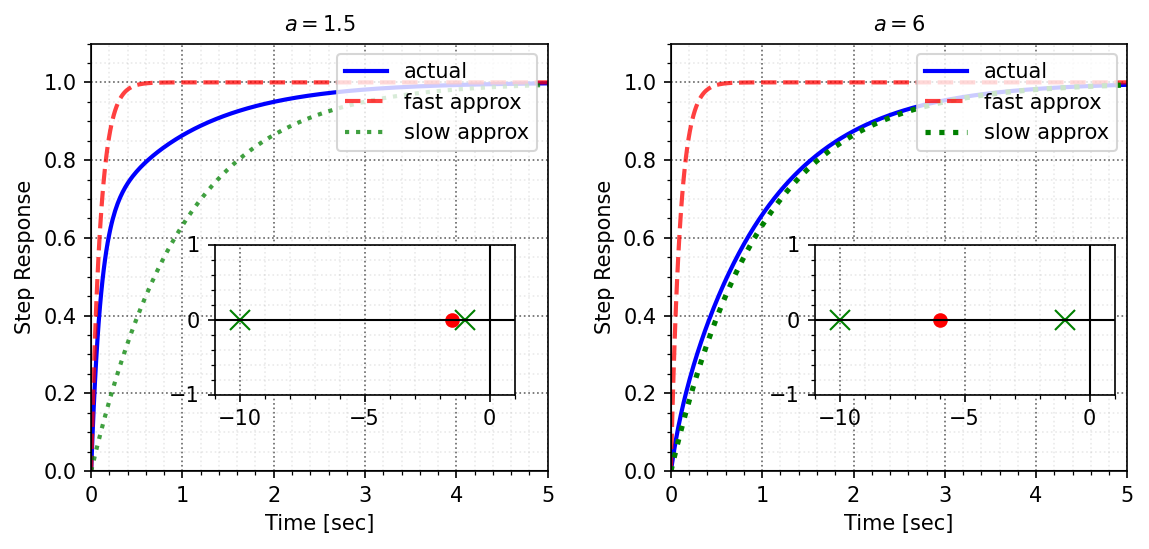

In [72]:
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,sharex = True)
y1,t = cmat.step(P(A[0]),5)
y2,t = cmat.step(P(A[1]),t)

ya1,t = cmat.step(Pa1,t)
ya2,t = cmat.step(Pa2,t)

ax[0].plot(t,y1,'b-',label='actual')
ax[0].plot(t,ya1,'r--',alpha=0.75,label='fast approx')
ax[0].plot(t,ya2,'g:',alpha=0.75,label='slow approx')
ax[1].plot(t,y2,'b-',label='actual')
ax[1].plot(t,ya1,'r--',alpha=0.75,label='fast approx')
ax[1].plot(t,ya2,'g:',alpha=1,label='slow approx',lw=2.5)

left, bottom, width, height = [0.2, 0.3, 0.25, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(P(A[0]).poles()),np.imag(P(A[0]).poles()), 'x', ms=10, color='green')
ax2.plot(np.real(P(A[0]).zeros()),np.imag(P(A[0]).zeros()), 'o', ms=6, color='red')
ax2.set_xlim((-11,1))
ax2.set_ylim((-1,1))
bm.nicegrid(ax,6)
bm.nicegrid(ax2,-6)

left, bottom, width, height = [0.7, 0.3, 0.25, 0.25]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.figure.set_facecolor('w')
ax3.plot(np.real(P(A[1]).poles()),np.imag(P(A[1]).poles()), 'x', ms=10, color='green')
ax3.plot(np.real(P(A[1]).zeros()),np.imag(P(A[1]).zeros()), 'o', ms=6, color='red')
ax3.set_xlim((-11,1))
ax3.set_ylim((-1,1))
bm.nicegrid(ax3,-6)

ax[0].set_title(rf"$a={A[0]}$")
ax[1].set_title(rf"$a={A[1]}$")

for ii in range(2):
    ax[ii].set_ylim((0,1.1)) 
    ax[ii].set_xlabel("Time [sec]")
    ax[ii].set_ylabel("Step Response")
    ax[ii].legend(loc=1)
plt.savefig("./figs/zero_res.pdf", dpi=600)
plt.show()